In [1]:
import pandas as pd
import numpy as np

In [4]:
full_data = pd.read_csv("../data/full_data.csv", index_col="Unnamed: 0")

C:\Users\miale.a\AppData\Local\Temp\ipykernel_32936\1255718291.py:1: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  full_data = pd.read_csv("../data/full_data.csv", index_col="Unnamed: 0")


In [5]:
full_data.head()

,x,y,player_id,is_detected,frame,timestamp,period,possession_player_id,possession_group,ball_x,...,team_in_possession_phase_type,player_targeted_dangerous,runner,ball_carrier,tip,vx_kmh,vy_kmh,speed_kmh,ax_kmh2,ay_kmh2
0,-40.71,-0.27,51009,False,28,2026-03-31 00:00:01.800,1.0,966120.0,away team,0.03,...,create,NaN,False,False,True,0.0,0.0,0.0,0.0,0.0
1,-19.33,-9.63,176224,True,28,2026-03-31 00:00:01.800,1.0,966120.0,away team,0.03,...,create,NaN,False,False,True,0.0,0.0,0.0,0.0,0.0
2,-21.72,0.22,51649,True,28,2026-03-31 00:00:01.800,1.0,966120.0,away team,0.03,...,create,NaN,False,False,True,0.0,0.0,0.0,0.0,0.0
3,-0.64,-33.03,50983,True,28,2026-03-31 00:00:01.800,1.0,966120.0,away team,0.03,...,create,NaN,False,False,True,0.0,0.0,0.0,0.0,0.0
4,-20.11,15.75,735578,True,28,2026-03-31 00:00:01.800,1.0,966120.0,away team,0.03,...,create,NaN,False,False,True,0.0,0.0,0.0,0.0,0.0


In [6]:
print(full_data.columns)

Index(['x', 'y', 'player_id', 'is_detected', 'frame', 'timestamp', 'period',
       'possession_player_id', 'possession_group', 'ball_x', 'ball_y',
       'ball_z', 'is_detected_ball', 'match_id', 'start_time', 'end_time',
       'match_name', 'date_time', 'home_team.name', 'away_team.name', 'id',
       'short_name', 'number', 'team_id', 'team_name',
       'player_role.position_group', 'total_time', 'player_role.name',
       'player_role.acronym', 'is_gk', 'direction_player_1st_half',
       'direction_player_2nd_half', 'player_id_event', 'frame_start',
       'frame_end', 'event_id', 'event_type', 'team_id_event',
       'player_in_possession_id', 'lead_to_shot', 'lead_to_goal',
       'team_in_possession_phase_type', 'player_targeted_dangerous', 'runner',
       'ball_carrier', 'tip', 'vx_kmh', 'vy_kmh', 'speed_kmh', 'ax_kmh2',
       'ay_kmh2'],
      dtype='object')


In [11]:
# get target variable
target= full_data["lead_to_goal"]
print(target[0:5])

0    False
1    False
2    False
3    False
4    False
Name: lead_to_goal, dtype: bool


In [12]:
# convert 0/1
target = list(map(lambda x: 0 if x == False else 1, y))

In [13]:
print(target[0:5])

[0, 0, 0, 0, 0]


In [51]:
# identify necessary columns 
cols = ["x", "y", "frame", "ball_x", "ball_y", "ball_z", "event_id", 'team_in_possession_phase_type', 'vx_kmh', 'vy_kmh', 'speed_kmh', 'ax_kmh2',
       'ay_kmh2']

frame is necessary for us when we flatten the data into one row per frame. it can be dropped after that transformation

In [8]:
print(full_data["event_type"].value_counts())

event_type
passing_option        5766252
on_ball_engagement    3173846
player_possession     3115745
off_ball_run          2841174
Name: count, dtype: int64


I think including only events with player posssession as event type is necessary. passing options and on ball engagements will just be the same row (I think) with just event_type changed. It would also speed up training time by a mile

In [28]:
match = full_data["match_id"][0]
match_data = full_data[full_data["match_id"]==match]

In [33]:
print(match_data["frame"].drop_duplicates().describe())
frame = match_data["frame"].drop_duplicates()

count    22182.000000
mean     26299.621134
std      16855.102860
min         28.000000
25%      11639.250000
50%      24746.500000
75%      40869.750000
max      58932.000000
Name: frame, dtype: float64


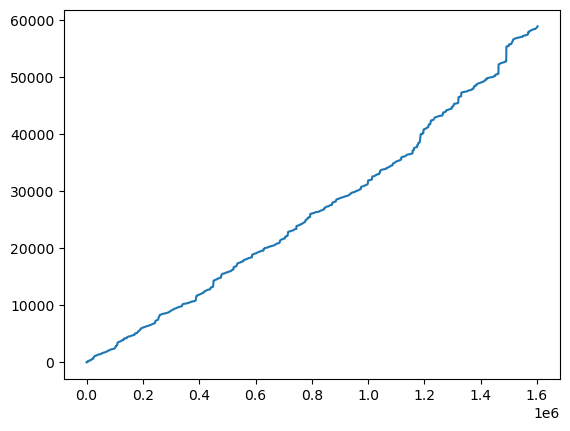

In [34]:
import matplotlib.pyplot as plt
plt.plot(frame)

In [40]:
# look at possession types
print(full_data["team_in_possession_phase_type"].value_counts())

team_in_possession_phase_type
create         5443856
finish         4355646
build_up       2141509
chaotic         999475
transition      695904
direct          569544
quick_break     311631
set_play        310267
disruption       69185
Name: count, dtype: int64


In [7]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()

In [8]:
phase = full_data["team_in_possession_phase_type"].to_numpy().reshape(-1,1)
enc.fit(phase)
enc.categories_

[array(['build_up', 'chaotic', 'create', 'direct', 'disruption', 'finish',
        'quick_break', 'set_play', 'transition'], dtype=object)]

In [67]:
temp = enc.transform(phase).toarray()

In [68]:
print(temp[0:10])

[[0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]]


In [78]:
print(enc.transform(np.array(["finish"]).reshape(-1, 1)).toarray())

[[0. 0. 0. 0. 0. 1. 0. 0. 0.]]


One hot encoded vector for phase type, might be useful for epv. need to add to each frame. I think best practice is to use the encoder to encode the parameter during flattening to avoid compute and taking up space, also then we are only computing one encoding per frame instead of 22.

Need to do: flatten

maybe change direction so play is always going in the same direction

In [9]:
PITCH_WIDTH = 68
PITCH_LENGTH = 105

width_min = -PITCH_WIDTH/2
width_max = PITCH_WIDTH/2
length_min = -PITCH_LENGTH/2
length_max = PITCH_LENGTH/2

In [10]:
# run this cell for x, y min max scaling
x = full_data["x"]
y = full_data["y"]

x = list(map(lambda loc: (loc-length_min)/(length_max-length_min), x))
print(f"x min: {min(x)}\nx max: {max(x)}")

y = list(map(lambda loc: (loc-width_min)/(width_max-width_min), y))
print(f"y min: {min(y)}\ny max: {max(y)}")

x min: -0.04523809523809524
x max: 1.0475238095238095
y min: -0.09632352941176467
y max: 1.1244117647058824


Skill corner data isn't perfect so some values are off the field. Not too big of an issue this will still reduce compute

In [11]:
# run cell to min max scale acceleration and velocity
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data = full_data[['vx_kmh', 'vy_kmh', 'speed_kmh', 'ax_kmh2', 'ay_kmh2']]
scaled = scaler.fit_transform(data)

In [12]:
# check values

print(f"Mix vx_kmh: {min(scaled[:, 0])}, Max vx_kmh: {max(scaled[:, 0])}")
print(f"Mix vy_kmh: {min(scaled[:, 1])}, Max vy_kmh: {max(scaled[:, 1])}")
print(f"Mix speed_kmh: {min(scaled[:, 2])}, Max speed_kmh: {max(scaled[:, 2])}")
print(f"Mix ax_kmh2: {min(scaled[:, 3])}, Max ax_kmh2: {max(scaled[:, 3])}")
print(f"Mix ay_kmh2: {min(scaled[:, 4])}, Max ay_kmh2: {max(scaled[:, 4])}")

Mix vx_kmh: 0.0, Max vx_kmh: 1.0
Mix vy_kmh: 0.0, Max vy_kmh: 1.0
Mix speed_kmh: 0.0, Max speed_kmh: 1.0
Mix ax_kmh2: 0.0, Max ax_kmh2: 1.0
Mix ay_kmh2: 0.0, Max ay_kmh2: 1.0


looks good

In [59]:
auckland_newcastle = full_data[full_data["match_name"]=="Auckland FC vs Newcastle United Jets FC"].sort_values("frame").reset_index()
print(auckland_newcastle[auckland_newcastle["frame"]==48]["event_type"][0:50])

22       passing_option
23       passing_option
24       passing_option
25       passing_option
26       passing_option
27       passing_option
28       passing_option
29       passing_option
30       passing_option
31       passing_option
32       passing_option
33       passing_option
34       passing_option
35       passing_option
36       passing_option
37       passing_option
38       passing_option
39       passing_option
40       passing_option
41       passing_option
42       passing_option
43       passing_option
44       passing_option
45       passing_option
46       passing_option
47       passing_option
48       passing_option
49       passing_option
50       passing_option
51       passing_option
52       passing_option
53       passing_option
54       passing_option
55       passing_option
56       passing_option
57       passing_option
58       passing_option
59       passing_option
60       passing_option
61       passing_option
62       passing_option
63       passing

two passing option events and one player possession

In [62]:
print(auckland_newcastle[auckland_newcastle["frame"]==48][['x', 'y']].value_counts())

x       y     
-40.38   0.18     3
-22.31   1.22     3
 18.17  -5.13     3
 17.07  -16.06    3
 16.67   3.78     3
 14.67   13.89    3
 7.70   -19.78    3
 7.33    7.03     3
 6.72   -2.53     3
 5.45    9.58     3
 4.47   -19.75    3
 4.30    0.32     3
 4.23   -32.28    3
 1.17    16.62    3
 0.99    15.50    3
-4.63    7.43     3
-4.91    9.89     3
-8.76   -3.09     3
-10.47  -2.78     3
-20.69   16.66    3
-21.43  -10.04    3
 41.47  -0.01     3
Name: count, dtype: int64


players don't move across the 3 sets of frames, so I think we should only use frames where the event_type is player possession

In [63]:
print(auckland_newcastle[auckland_newcastle["frame"]==48][['x', 'y', 'vx_kmh', 'vy_kmh', 'speed_kmh', 'ax_kmh2', 'ay_kmh2']].value_counts())

x       y       vx_kmh    vy_kmh    speed_kmh  ax_kmh2  ay_kmh2 
 0.99    15.50   0.0000    0.0000   0.000000   0.0000    0.0000     2
-4.91    9.89    0.0000    0.0000   0.000000   0.0000    0.0000     2
-40.38   0.18    0.0495    0.0675   0.083705   0.0000    0.0000     1
 7.70   -19.78   8.8560    5.4720   10.410164  6.5880    4.0140     1
 4.47   -19.75   13.3920   2.1240   13.559389  12.5580   2.0130     1
                                                                   ..
 1.17    16.62   17.2080  -15.4080  23.098089  12.1500  -11.1780    1
 4.23   -32.28   0.7305    0.1125   0.739112   0.0000    0.0000     1
                 11.5020   1.7100   11.628418  10.7715   1.5975     1
                 37.8000   5.7600   38.236339  26.2980   4.0500     1
 41.47  -0.01   -1.8900    0.4500   1.942833   1.4175   -0.3375     1
Name: count, Length: 64, dtype: int64


but they change direction and speed

In [20]:
flatten_data = full_data[full_data["event_type"]=="player_possession"]
print(flatten_data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 3115745 entries, 0 to 14896950
Data columns (total 51 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   x                              float64
 1   y                              float64
 2   player_id                      int64  
 3   is_detected                    bool   
 4   frame                          int64  
 5   timestamp                      object 
 6   period                         float64
 7   possession_player_id           float64
 8   possession_group               object 
 9   ball_x                         float64
 10  ball_y                         float64
 11  ball_z                         float64
 12  is_detected_ball               bool   
 13  match_id                       int64  
 14  start_time                     object 
 15  end_time                       object 
 16  match_name                     object 
 17  date_time                      object 
 18  home_t

In [50]:
temp = match_data["frame"].to_numpy()
temp = np.unique(temp)
print(temp) # all frames in this match

[   28    48    49 ... 58930 58931 58932]


In [51]:
match_ids = full_data["match_id"].to_numpy()
match_ids = np.unique(match_ids)
print(match_ids) # all match ids

[1886347 1899585 1925299 1953632 1996435 2006229 2011166 2013725 2015213
 2017461]


Loop to flatten data

In [96]:
flatten_columns = ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8", "x9", "x10", "x11", 
                   "x12", "x13", "x14", "x15", "x16", "x17", "x18", "x19", "x20", "x21", "x22",
                   "y1", "y2", "y3", "y4", "y5", "y6", "y7", "y8", "y9", "y10", "y11", 
                   "y12", "y13", "y14", "y15", "y16", "y17", "y18", "y19", "y20", "y21", "y22",
                   "vx1", "vx2", "vx3", "vx4", "vx5", "vx6", "vx7", "vx8", "vx9", "vx10", "vx11",
                   "vx12", "vx13", "vx14", "vx15", "vx16", "vx17", "vx18", "vx19", "vx20", "vx21", "vx22",
                   "vy1", "vy2", "vy3", "vy4", "vy5", "vy6", "vy7", "vy8", "vy9", "vy10", "vy11", 
                   "vy12", "vy13", "vy14", "vy15", "vy16", "vy17", "vy18", "vy19", "vy20", "vy21", "vy22",
                   "speed1", "speed2", "speed3", "speed4", "speed5", "speed6", "speed7", "speed8", "speed9", "speed10", "speed11", 
                   "speed12", "speed13", "speed14", "speed15", "speed16", "speed17", "speed18", "speed19", "speed20", "speed21", "speed22",
                   "ax1", "ax2", "ax3", "ax4", "ax5", "ax6", "ax7", "ax8", "ax9", "ax10", "ax11", 
                   "ax12", "ax13", "ax14", "ax15", "ax16", "ax17", "ax18", "ax19", "ax20", "ax21", "ax22",
                   "ay1", "ay2", "ay3", "ay4", "ay5", "ay6", "va7", "ay8", "ay9", "ay10", "ay11",
                   "ay12", "ay13", "ay14", "ay15", "ay16", "ay17", "ay18", "ay19", "ay20", "ay21", "ay22",
                   "ball_x", "ball_y", "ball_z", 'build_up', 'chaotic', 'create', 'direct', 'disruption', 
                   'finish', 'quick_break', 'set_play', 'transition', "direction", "lead_to_goal"]
flatten_df = pd.DataFrame(columns=flatten_columns)

for match_id in match_ids: # for each match
    print(f"Processing data for match {match_id}")
    match = full_data[full_data["match_id"] == 1899585]
    frames = match["frame"].to_numpy() # get the frames of this match
    frames = np.unique(frames) # remove duplicates
    for frame in frames:
        # take first 22 values, some frames are duplicated
        full_frame = match[match["frame"]==frame][0:22]
        while full_frame.empty: # if frame is empty, keep trying until it works
            # sometimes pandas returns empty frame, this catches the error and tries again
            full_frame = match[match["frame"]==frame][0:22]
        x = full_frame["x"].to_numpy().T # convert to numpy and transpose to make row
        y = full_frame["y"].to_numpy().T
        vx = full_frame["vx_kmh"].to_numpy().T
        vy = full_frame["vy_kmh"].to_numpy().T
        speed = full_frame["speed_kmh"].to_numpy().T
        ax = full_frame["ax_kmh2"].to_numpy().T
        ay = full_frame["ay_kmh2"].to_numpy().T
        ball_x = full_frame["ball_x"].iloc[0]
        ball_y = full_frame["ball_y"].iloc[0]
        ball_z = full_frame["ball_z"].iloc[0]
        phase = full_frame["team_in_possession_phase_type"].iloc[0]
        phase = enc.transform(np.array(phase).reshape(-1, 1)).toarray()[0]
        direction = 0 if full_frame["direction_player_1st_half"].iloc[0] == "left_to_right" else 1
        lead_to_goal = 0 if full_frame["lead_to_goal"].iloc[0] == False else 1
        full_array = np.concatenate((x, y, vx, vy, speed, ax, ay, ball_x, ball_y, ball_z, phase, direction, lead_to_goal), axis=None)
        if len(full_array) != 168:
            print(frame)
        flatten_df.loc[len(flatten_df)] = full_array

flatten_df.to_csv("flatten_data.csv", float_format="%.2f", index=False)

Processing data for match 1886347
1138


ValueError: cannot set a row with mismatched columns

In [97]:
print(full_data[full_data["frame"]==1138])

              x      y  player_id  is_detected  frame  \
29502    -27.30  -6.32      51009        False   1138   
29503      7.43 -29.04     176224         True   1138   
29504      3.17 -14.94      51649         True   1138   
29505     27.21 -32.63      50983        False   1138   
29506      7.22  -0.15     735578         True   1138   
...         ...    ...        ...          ...    ...   
13506671   2.96  -3.14      51046         True   1138   
13506672  15.96  -4.27      23909         True   1138   
13506673   2.35 -15.44      26969         True   1138   
13506674   9.38  17.57      27003         True   1138   
13506675   1.82  25.77       4322         True   1138   

                        timestamp  period  possession_player_id  \
29502     2026-03-31 00:01:52.800     1.0                   NaN   
29503     2026-03-31 00:01:52.800     1.0                   NaN   
29504     2026-03-31 00:01:52.800     1.0                   NaN   
29505     2026-03-31 00:01:52.800     1.0      